# Análise Exploratória — Diabetes 130-US Hospitals

## 1. Setup e carregamento dos dados

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
print(pd.__version__)

2.3.3


## 2. Inspeção inicial e estrutura

In [142]:
df = pd.read_csv("../data/raw/diabetic_data.csv", na_values='?',keep_default_na=False)


C:\Users\vvfpi\AppData\Local\Temp\ipykernel_12688\2148320682.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/diabetic_data.csv", na_values='?',keep_default_na=False)


In [143]:
df.columns[10]

'payer_code'

In [144]:
df["payer_code"].unique()[:30] 

array([nan, 'MC', 'MD', 'HM', 'UN', 'BC', 'SP', 'CP', 'SI', 'DM', 'CM',
       'CH', 'PO', 'WC', 'OT', 'OG', 'MP', 'FR'], dtype=object)

In [145]:
df.shape

(101766, 50)

In [146]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [147]:
df.dtypes.value_counts()

object    37
int64     13
Name: count, dtype: int64

**Inspeção inicial**

O dataset contém **101.766 encontros hospitalares** distribuídos por **50 variáveis**, das quais 13 são numéricas (`int64`) e 37 são categóricas (`object`). Esta predominância de variáveis categóricas vai exigir codificação cuidada na fase de pré-processamento ,em particular para variáveis de alta cardinalidade como os códigos de diagnóstico (`diag_1`, `diag_2`, `diag_3`).

A coluna `payer_code` (índice 10) gerou um `DtypeWarning` no carregamento por conter valores mistos, mas a inspeção dos valores únicos revela que se trata simplesmente de códigos categóricos curtos (e.g., `MC`, `MD`, `HM`, `BC`) que codificam o tipo de cobertura financeira do utente. Não constitui anomalia que justifique tratamento especial nesta fase.

A estrutura dos dados confirma a natureza relacional esperada: cada linha representa um **encontro hospitalar** identificado por `encounter_id`, ligado a um doente via `patient_nbr`. Múltiplos encontros do mesmo doente partilham o mesmo `patient_nbr`, o que justificará a estratégia de *split* por grupo (`GroupShuffleSplit`) na fase de modelação para prevenir *patient-level leakage*.

## 3. Variável-alvo: distribuição e binarização

In [148]:
df["readmitted"]

0          NO
1         >30
2          NO
3          NO
4          NO
         ... 
101761    >30
101762     NO
101763     NO
101764     NO
101765     NO
Name: readmitted, Length: 101766, dtype: object

In [149]:
df["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [150]:
(df["readmitted"].value_counts(normalize=True) * 100).round(2)

readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64

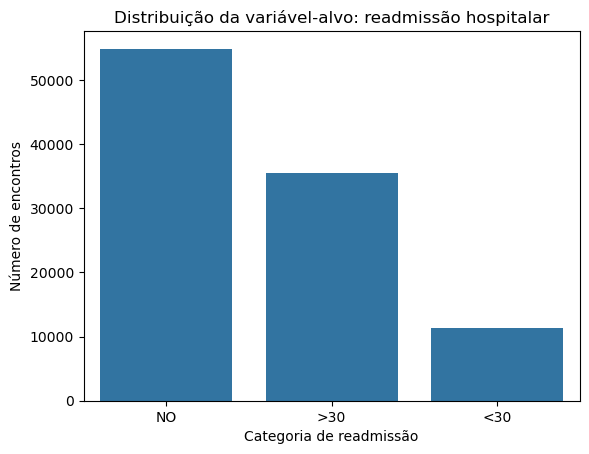

In [151]:
sns.countplot(data=df, x="readmitted", order=["NO", ">30", "<30"])
plt.title("Distribuição da variável-alvo: readmissão hospitalar")
plt.xlabel("Categoria de readmissão")
plt.ylabel("Número de encontros")
plt.show()

In [152]:
df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)
df["readmitted_30"]

0         0
1         0
2         0
3         0
4         0
         ..
101761    0
101762    0
101763    0
101764    0
101765    0
Name: readmitted_30, Length: 101766, dtype: int32

In [153]:
df["readmitted_30"].value_counts()

readmitted_30
0    90409
1    11357
Name: count, dtype: int64

In [154]:
(df["readmitted_30"].value_counts(normalize=True) * 100).round(2)

readmitted_30
0    88.84
1    11.16
Name: proportion, dtype: float64

In [155]:
prevalencia=(df["readmitted_30"].value_counts(normalize=True) * 100).round(2).iloc[1]
print(f"Prevalência da classe (<30 dias): {prevalencia}%")

Prevalência da classe (<30 dias): 11.16%


**Inspeção da variável-alvo**

A variável `readmitted` distribui-se em três categorias: **54.864 encontros sem readmissão (53.91%)**, **35.545 com readmissão tardia, >30 dias (34.93%)**, e **11.357 com readmissão precoce, <30 dias (11.16%)**.

A **binarização** adotada agrupa **"sem readmissão" e ">30 dias"** como **classe negativa (0)** e **"<30 dias"** como **classe positiva (1)**. Esta escolha tem fundamentação clínica e regulatória: a janela de 30 dias é a única em que a readmissão é razoavelmente atribuível à qualidade do internamento anterior e em que existe margem para intervenção preventiva à alta (reconciliação medicamentosa, *follow-up* precoce, programas de transição de cuidados). É também a métrica oficialmente monitorizada pelo CMS nos EUA e por sistemas de saúde europeus equivalentes.

A prevalência da classe positiva é de 11.16%, configurando um cenário de *class imbalance* moderado (rácio ~89:11). Esta característica condiciona a fase de modelação: a *accuracy* deixa de ser métrica informativa (um classificador trivial que prevê sempre "0" atinge 88.84%), exigindo o uso de AUC-ROC, AUC-PR, *precision* e *recall* na classe positiva. Tecnicamente, o desequilíbrio será endereçado começando por `class_weight='balanced'` no modelo *baseline*, com técnicas mais avançadas (*sample weights* por doente, SMOTE) a serem exploradas como ablações posteriores.

## 4. Análise de missing values

In [156]:
df.isna().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [157]:

missing_count = df.isna().sum()
df_nan = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": (missing_count / len(df) * 100).round(2)
})
df_nan = df_nan[df_nan["missing_count"] > 0].sort_values("missing_pct", ascending=False)
df_nan

,missing_count,missing_pct
weight,98569,96.86
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


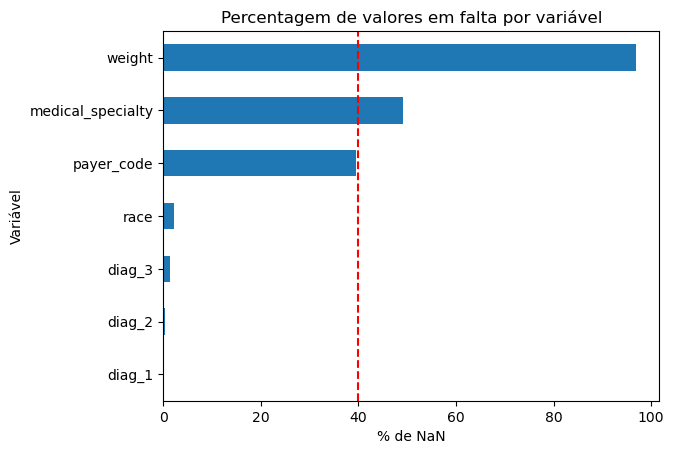

In [158]:
df_nan=df_nan.sort_values("missing_pct", ascending=True)
df_nan["missing_pct"].plot(kind="barh")
plt.title("Percentagem de valores em falta por variável")
plt.xlabel("% de NaN")
plt.ylabel("Variável")
plt.axvline(x=40, color='red', linestyle='--')

**Inspeção da missing Values**

**`weight` (96.86% em falta)**

*Definição clínica:* peso corporal do doente em libras.

*Causa provável do missing:* Pesar doentes em ambiente hospitalar agudo é estruturalmente difícil, exige cama-balança, mobilização do doente, tempo de enfermagem. Em medicina interna típica do período do dataset (1999–2008), não fazia parte do protocolo de admissão sistemático. O missing reflete provavelmente decisões organizacionais (que tipo de unidade pesa) mais do que decisão clínica caso a caso.

*Tipo de missingness:* difícil de classificar com certeza sem dados sobre tipo de unidade. Plausivelmente uma mistura de MAR (depende da unidade, que é variável observada) e MCAR (variação aleatória entre hospitais).

*Tratamento proposto:* descartar a variável dado o nível de ausência (~97%), mas considerar criar uma feature binária `weight_recorded` (1 se medido, 0 caso contrário) que pode capturar o tipo de unidade ou intensidade de cuidados.

**`max_glu_serum` e `A1Cresult` (categoria semântica `None` em ~95% e ~83% dos encontros)**

*Nota metodológica:* estas duas variáveis não aparecem na tabela de missing values acima porque o dataset codifica explicitamente o estado "exame não realizado" com a string `None`, tratada aqui como categoria válida e não como missing. A análise abaixo refere-se à frequência desta categoria semântica, não a missing values no sentido estrito.

*Definição clínica:* `max_glu_serum` indica o intervalo da glicemia sérica máxima medida durante o internamento (`>200`, `>300`, `Norm`, `None`). `A1Cresult` indica o intervalo da hemoglobina glicada (`>8`, `>7`, `Norm`, `None`). A1c reflete o controlo glicémico médio dos últimos 2-3 meses; glicemia sérica é uma medição pontual.

*Razão provável da não-realização:* ambos os exames são pedidos por decisão clínica explícita, não realizados sistematicamente. O médico solicita-os quando suspeita de descompensação diabética, mau controlo glicémico, ou quando o histórico do doente o justifica. A não-realização não é esquecimento — é decisão.

*Interpretação como confounding by indication:* a decisão de medir é, ela própria, função do estado clínico do doente. Doentes mais complexos têm maior probabilidade de A1c medido e simultaneamente maior risco de readmissão. O valor `None` é, portanto, informação preditiva — codifica "doente em quem o clínico não suspeitou de descompensação".

*Tratamento proposto:* tratar como variáveis categóricas normais com 4 níveis. A categoria `None` será preservada como nível próprio em qualquer codificação dummy/one-hot, mantendo intacta esta informação preditiva.

**`medical_specialty` (49.08% em falta)**

*Definição clínica:* especialidade médica do médico que admitiu o doente, com 84 valores distintos (e.g., `Cardiology`, `InternalMedicine`, `Family/GeneralPractice`, `Surgery`).

*Causa provável do missing:* registo administrativo inconsistente entre hospitais. Hospitais maiores com serviços diferenciados tendem a registar especialidade; hospitais menores onde clínicos gerais cobrem múltiplas funções podem omitir o campo.

*Tipo de missingness:* provavelmente MAR, o missing está correlacionado com tipo/dimensão do hospital, que por sua vez correlaciona-se indiretamente com complexidade dos doentes admitidos. Não é um MNAR puro, mas também não é totalmente neutro face ao desfecho. Será confirmado empiricamente na secção seguinte (comparação de taxa de readmissão entre presente vs. ausente).

*Tratamento proposto:* não descartar. Agrupar os 84 valores em poucas categorias clinicamente coerentes (Cirurgia / Medicina Interna / Cardiologia / Família-Geral / Outros / Desconhecido), com `Desconhecido` como categoria explícita preservando o sinal do missing.

**`payer_code` (39.56% em falta)**

*Definição clínica:* tipo de cobertura financeira do internamento, com 23 valores distintos (e.g., `MC` Medicare, `MD` Medicaid, `BC` Blue Cross, `SP` self-pay).

*Causa provável do missing:* registo administrativo inconsistente, alguns hospitais não codificam sistematicamente o pagador no momento da admissão.

*Tipo de missingness:* provavelmente MAR. O missing depende de práticas administrativas hospitalares, não diretamente do desfecho. Mas atenção: se hospitais com pior registo administrativo servirem populações específicas, pode haver correlação indireta com risco de readmissão.

*Tratamento proposto:* agrupar em categorias com significado socioeconómico — `Medicare/Medicaid` (público, doentes mais idosos ou de baixos rendimentos), `Privado` (Blue Cross e equivalentes), `Self-pay` (sem seguro, indicador de vulnerabilidade), `Desconhecido` (missing). Esta variável captura dimensão socioeconómica indireta (acesso a cuidados primários, suporte social, literacia em saúde) que sabidamente influencia readmissão. Manter no modelo, mas marcar para análise de *algorithmic fairness* na fase final: modelos que aprendem este sinal podem perpetuar desigualdades de acesso a cuidados.


In [159]:
(df.groupby(df["medical_specialty"].isna())["readmitted_30"].mean() * 100).round(2)

medical_specialty
False    10.76
True     11.57
Name: readmitted_30, dtype: float64

In [160]:
(df.groupby(df["payer_code"].isna())["readmitted_30"].mean() * 100).round(2)

payer_code
False    10.94
True     11.49
Name: readmitted_30, dtype: float64

**Síntese da análise de missing values**

Das 50 variáveis do dataset, 7 contêm valores em falta no sentido estrito, e apenas 3 atingem dimensão relevante (≥40%) — `weight` (96.86%), `medical_specialty` (49.08%) e `payer_code` (39.56%). As restantes 4 (`race`, `diag_1`, `diag_2`, `diag_3`) apresentam ausências marginais (<3%) tratáveis trivialmente.

As variáveis `max_glu_serum` e `A1Cresult` não aparecem nesta análise apesar de terem ~95% e ~83% dos encontros codificados como `None` (exame não realizado), porque `None` é uma categoria semântica válida no dataset original e não missing — a decisão clínica de não medir é informação preditiva e não dado em falta. Estas variáveis são tratadas em detalhe no bloco anterior.

A análise empírica testou se a ausência de registo nas variáveis administrativas (`medical_specialty`, `payer_code`) tem associação com o desfecho. As diferenças observadas são pequenas: 10.76% vs 11.57% para `medical_specialty` e 10.94% vs 11.49% para `payer_code`. Em ambas, o grupo com missing apresenta taxa de readmissão ligeiramente superior — consistente com a hipótese de que registo administrativo deficiente correlaciona com hospitais ou populações de maior risco — mas a magnitude (~0.5–0.8 pontos percentuais) é insuficiente para justificar tratamento especial.

**Decisões de tratamento para a fase de pré-processamento:**

- `weight`: descartar (97% em falta torna inviável imputação fiável). Considerar feature binária `weight_recorded` como ablação posterior.
- `max_glu_serum` e `A1Cresult`: manter como variáveis categóricas com 4 níveis, preservando `None` como categoria explícita em qualquer codificação dummy/one-hot. A interpretação como *confounding by indication* (a decisão de medir é, ela própria, informativa) é preservada operacionalmente.
- `medical_specialty`: agrupar os 84 valores em poucas categorias clinicamente coerentes, com `Desconhecido` como nível próprio.
- `payer_code`: agrupar em categorias com significado socioeconómico (`Medicare/Medicaid`, `Privado`, `Self-pay`, `Desconhecido`); marcar para análise de *fairness* posterior.
- `race`, `diag_1-3`: imputação simples (moda ou categoria `Unknown`) na fase de pré-processamento.

## 5. Análise de doentes vs. encontros

In [161]:
encounter_num = len(df)
patient_num=df["patient_nbr"].nunique()
raz=encounter_num/patient_num
print(f"Número de encontros: {encounter_num}")
print(f"Doentes no dataset: {patient_num}")
print(f"Razão encontros/doente: {raz:.2f}")


Número de encontros: 101766
Doentes no dataset: 71518
Razão encontros/doente: 1.42


In [162]:
patient_encounter = df["patient_nbr"].value_counts()
patient_encounter.head()


patient_nbr
88785891    40
43140906    28
1660293     23
88227540    23
23199021    23
Name: count, dtype: int64

In [163]:
patient_encounter.describe()

count    71518.000000
mean         1.422942
std          1.090740
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         40.000000
Name: count, dtype: float64

In [164]:
n_1 = (patient_encounter == 1).sum()
n_2 = (patient_encounter == 2).sum()
n_3_5 = ((patient_encounter >= 3) & (patient_encounter <= 5)).sum()
n_5plus = (patient_encounter > 5).sum()
counts = [n_1, n_2, n_3_5, n_5plus]
patient_encounter_tab = pd.DataFrame({
    "Encontros": ["1", "2", "3-5", ">5"],
    "Nº doentes": [n_1, n_2, n_3_5, n_5plus],
    "% do total": [c/patient_num*100 for c in counts]
})
patient_encounter_tab.round(2)

,Encontros,Nº doentes,% do total
0,1,54745,76.55
1,2,10434,14.59
2,3-5,5466,7.64
3,>5,873,1.22


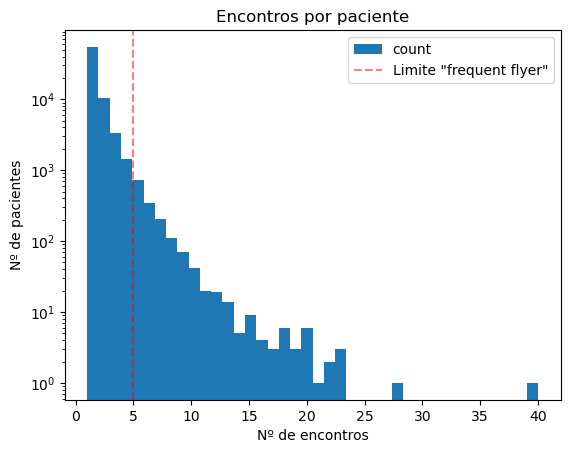

In [165]:
patient_encounter.plot(kind="hist", bins=40)
plt.yscale("log")
plt.title("Encontros por paciente")
plt.xlabel("Nº de encontros")
plt.ylabel("Nº de pacientes")
plt.axvline(x=5, color='red', linestyle='--', alpha=0.5, label='Limite "frequent flyer"')
plt.legend()
plt.show()

**Síntese — estrutura encontros vs. doentes**

O dataset contém 101.766 encontros distribuídos por 71.518 doentes únicos, configurando uma razão média de 1.42 encontros/doente, com mínimo de 1 e máximo de 40 encontros num único doente.

A distribuição é fortemente assimétrica: 76.55% dos doentes têm apenas 1 encontro, 14.59% têm 2, e a frequência decai até 1.22% para doentes com mais de 5 encontros, uma estrutura típica de *power-law* na utilização de cuidados, conhecida na literatura clínica como o problema dos *frequent flyers*. A forte assimetria motivou o uso de escala logarítmica no eixo y do histograma, indispensável para tornar visível a cauda longa.

Esta estrutura agrupada exige o uso de `GroupShuffleSplit` por `patient_nbr` na fase de modelação, prevenindo o *patient leakage* que ocorreria com divisão aleatória de linhas: encontros do mesmo doente seriam repartidos entre treino e teste, permitindo ao modelo memorizar características individuais e inflacionar artificialmente as métricas de desempenho.


## 6. Hipóteses clínicas e exploração de variáveis-chave

**H1 — Idade.** Espero que a taxa de readmissão aumente com a idade, devido à acumulação de comorbilidades, embora não seja o fator dominante.

**H2 — Tempo de internamento.** Tensão entre dois mecanismos opostos: internamentos longos podem indicar maior acompanhamento (efeito protetor) ou maior gravidade (efeito de risco). Possível relação não-linear.

**H3 — Medição de A1c.** A decisão clínica de medir A1c durante o internamento pode ser, ela própria, um sinal de gravidade (confounding by indication) — doentes com A1c medido podem readmitir mais, não menos.

**H4 — Número de medicamentos.** Mais medicamentos refletem polifarmácia e multimorbilidade, com risco acrescido de interações e iatrogenia, prevendo maior readmissão.

**H5 — Visitas prévias (`number_inpatient`, `number_emergency`).** O melhor preditor de evento futuro é evento passado do mesmo tipo — espero forte associação positiva com readmissão.

**H6 — Payer code.** Tipo de seguro pode predizer readmissão indiretamente, refletindo acesso a cuidados primários, suporte social e literacia em saúde — com implicações éticas de fairness a discutir.

**Teste de Hipóteses**

In [166]:
df["age"].unique()

array(['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)',
       '[60-70)', '[70-80)', '[80-90)', '[90-100)'], dtype=object)

In [167]:
(df.groupby("age")["readmitted_30"].agg(["mean", "count"]) * [100, 1]).round(2)

,mean,count
age,,
[0-10),1.86,161
[10-20),5.79,691
[20-30),14.24,1657
[30-40),11.23,3775
[40-50),10.60,9685
[50-60),9.67,17256
[60-70),11.13,22483
[70-80),11.77,26068
[80-90),12.08,17197


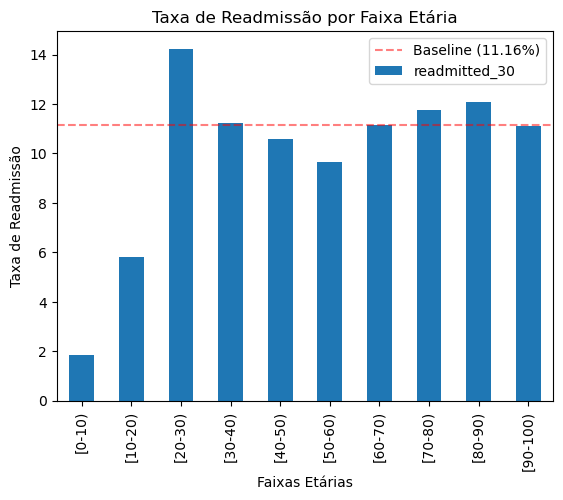

In [168]:
(df.groupby("age")["readmitted_30"].agg("mean") * 100).round(2).plot(kind="bar")
plt.title("Taxa de Readmissão por Faixa Etária")
plt.xlabel("Faixas Etárias")
plt.ylabel("Taxa de Readmissão")
plt.axhline(y=11.16, color='red', linestyle='--', alpha=0.5, label='Baseline (11.16%)')
plt.legend()
plt.show()

**H1 — Idade: parcialmente confirmada**

A tendência geral observada confirma a hipótese de aumento da taxa de readmissão com a idade no segmento adulto: a taxa sobe consistentemente de 9.67% em [50-60) para 11.13% em [60-70), 11.77% em [70-80) e atinge o pico em [80-90) com 12.08%. Este padrão é compatível com a acumulação de comorbilidades e fragilização clínica progressiva.

A faixa [90-100) apresenta uma ligeira redução para 11.10%, consistente com o efeito de *competing risk*: doentes muito idosos têm maior probabilidade de mortalidade pós-alta antes que a janela de 30 dias termine, removendo-os do denominador de potenciais readmissões.

A principal anomalia ocorre na faixa [20-30] com 14.24% - valor substancialmente acima da prevalência geral (11.16%) - e da própria média de adultos mais velhos. O grupo é, contudo, relativamente pequeno (n=1657 encontros) — cerca de 15× menor que a faixa de [70-80] — o que alarga o intervalo de confiança e exige cautela na interpretação. Ainda assim, a magnitude do efeito é consistente com uma hipótese clínica plausível: nesta faixa etária predomina a diabetes tipo 1 e a transição da gestão parental para auto-gestão da doença, frequentemente acompanhada de mau controlo glicémico, episódios de cetoacidose diabética e admissões recorrentes. 

O que motiva investigar mais aprofundadamente a variável insulina pois diabetes tipo 1 depende sempre de insulina, tipo 2 nem sempre.

In [169]:
df.groupby("age")["insulin"].value_counts().unstack()

insulin,Down,No,Steady,Up
age,,,,
[0-10),14,28,100,19
[10-20),114,110,329,138
[20-30),364,443,483,367
[30-40),601,1473,1121,580
[40-50),1451,4126,2833,1275
[50-60),2255,7780,5382,1839
[60-70),2675,10381,6924,2503
[70-80),2756,12937,7806,2569
[80-90),1727,8654,5069,1747


In [170]:
(df.groupby("age")["insulin"].value_counts(normalize=True).unstack() * 100).round(2)

insulin,Down,No,Steady,Up
age,,,,
[0-10),8.70,17.39,62.11,11.80
[10-20),16.50,15.92,47.61,19.97
[20-30),21.97,26.74,29.15,22.15
[30-40),15.92,39.02,29.70,15.36
[40-50),14.98,42.60,29.25,13.16
[50-60),13.07,45.09,31.19,10.66
[60-70),11.90,46.17,30.80,11.13
[70-80),10.57,49.63,29.94,9.85
[80-90),10.04,50.32,29.48,10.16


**Padrão de prescrição de insulina por faixa etária**

A análise da coluna `insulin` reforça a hipótese clínica do pico de readmissão em [20-30]. Em faixas etárias mais velhas (≥60 anos), aproximadamente metade dos doentes (49–51%) não recebe insulina durante o internamento, sugerindo predominância de diabetes tipo 2 controlada por antidiabéticos orais.

Na faixa [20-30], o padrão inverte-se: apenas 26.74% sem insulina, e — mais revelador — 44.12% com ajuste ativo de dose (`Up` ou `Down`), face a ~20% nas faixas idosas. Ajustar dose durante o internamento é sinal clínico de descompensação aguda (cetoacidose, hiperglicemia/hipoglicemia grave), padrão típico de diabetes tipo 1 mal controlada.

Esta evidência é consistente com — embora não prove — a hipótese de que o pico de readmissão nesta faixa é dirigido por diabetes tipo 1 com auto-gestão falhada. Confirmação rigorosa exigiria agrupamento dos códigos ICD-9 nos campos de diagnóstico (`diag_1`–`diag_3`), trabalho que será realizado na fase de pré-processamento. A natureza relativamente pequena da faixa (n=1657) recomenda também cautela na interpretação.

In [171]:
df["time_in_hospital"].dtype

dtype('int64')

In [172]:
df["time_in_hospital"].describe()

count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64

In [173]:
sorted(df["time_in_hospital"].unique())

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

In [174]:
(df.groupby("time_in_hospital")["readmitted_30"].agg(["mean", "count"]) * [100, 1]).round(2)

,mean,count
time_in_hospital,,
1,8.18,14208
2,9.94,17224
3,10.67,17756
4,11.81,13924
5,12.03,9966
6,12.59,7539
7,12.83,5859
8,14.23,4391
9,13.72,3002


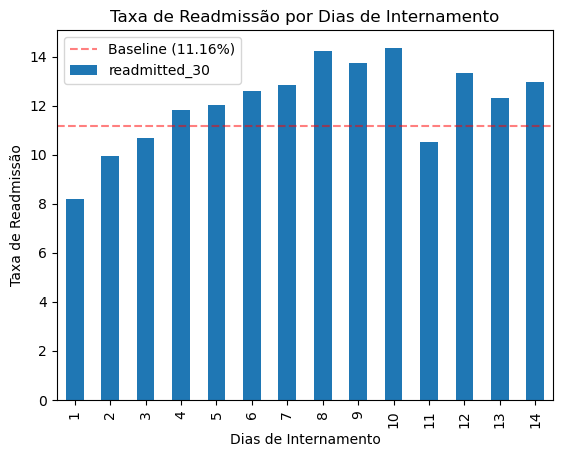

In [175]:
(df.groupby("time_in_hospital")["readmitted_30"].agg("mean") * 100).round(2).plot(kind="bar")
plt.title("Taxa de Readmissão por Dias de Internamento")
plt.xlabel("Dias de Internamento")
plt.ylabel("Taxa de Readmissão")
plt.axhline(y=11.16, color='red', linestyle='--', alpha=0.5, label='Baseline (11.16%)')
plt.legend()
plt.show()

**H2 — Tempo de internamento: parcialmente confirmada**

A relação entre `time_in_hospital` e taxa de readmissão é **monotónica crescente com saturação**: a taxa sobe acentuadamente nos primeiros dias (de 8.18% no dia 1 para 11.81% no dia 4), estabiliza entre os dias 4-7 (~11-13%), e atinge plateau entre 13-14% a partir do dia 8. **Dez dos catorze valores estão acima da baseline geral (11.16%)**.

A hipótese fica parcialmente confirmada: o efeito gravidade — internamentos longos como proxy de complexidade clínica — é dominante, enquanto o efeito protetor antecipado (mais cuidado durante internamento longo reduzindo readmissão) não se manifesta empiricamente, pelo menos não a um nível detetável que contrarie o efeito gravidade. A não-linearidade antecipada confirma-se: a relação não é linear simples e tem saturação clara, o que tem implicações diretas para a fase de modelação — modelos como regressão logística capturam mal este tipo de curvatura, justificando o uso de gradient boosting (XGBoost, LightGBM) como modelos principais.

A queda isolada observada no dia 11 (10.51%, n=1855) é provavelmente flutuação estatística sem significado clínico — o tamanho do grupo é razoável mas a magnitude da queda (de 14.23% no dia 8) é compatível com variação aleatória dentro do intervalo de confiança esperado. A partir do dia 12 o padrão retoma ao plateau de ~13%.

In [176]:
df["num_medications"].dtype

dtype('int64')

In [177]:
df["num_medications"].describe()

count    101766.000000
mean         16.021844
std           8.127566
min           1.000000
25%          10.000000
50%          15.000000
75%          20.000000
max          81.000000
Name: num_medications, dtype: float64

In [178]:
df["num_medications"].nunique()

75

In [179]:
df["num_meds_bin"] = pd.qcut(df["num_medications"], q=10, duplicates="drop")
(df.groupby("num_meds_bin", observed=True)["readmitted_30"].agg(["mean", "count"]) * [100, 1]).round(2)

,mean,count
num_meds_bin,,
"(0.999, 7.0]",8.12,11249
"(7.0, 9.0]",9.69,9266
"(9.0, 11.0]",10.18,11141
"(11.0, 13.0]",10.89,12090
"(13.0, 15.0]",11.21,11499
"(15.0, 17.0]",11.81,10349
"(17.0, 19.0]",12.21,8601
"(19.0, 22.0]",13.16,9789
"(22.0, 26.0]",12.81,8031


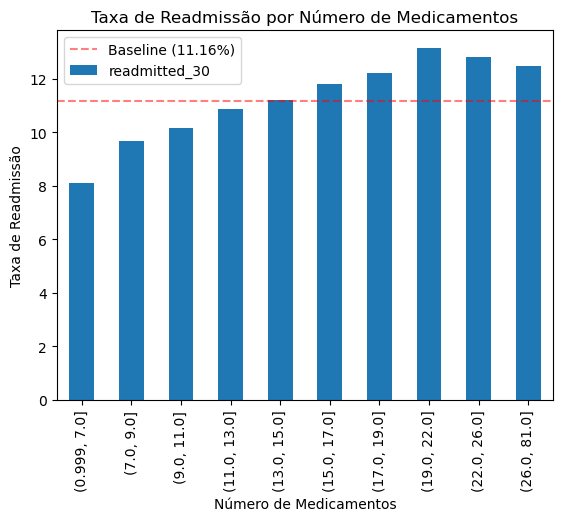

In [180]:
(df.groupby("num_meds_bin", observed=True)["readmitted_30"].agg("mean")*100).round(2).plot(kind="bar")
plt.title("Taxa de Readmissão por Número de Medicamentos")
plt.xlabel("Número de Medicamentos")
plt.ylabel("Taxa de Readmissão")
plt.axhline(y=11.16, color='red', linestyle='--', alpha=0.5, label='Baseline (11.16%)')
plt.legend()
plt.show()

**H4 — Número de medicamentos: confirmada com nuance**

A relação entre `num_medications` e taxa de readmissão é fortemente positiva e quase monotónica. A taxa sobe progressivamente de 8.12% nos doentes com 1-7 medicamentos para 13.16% no bin de 19-22 medicamentos — uma diferença absoluta de 5pp, equivalente a um risco relativo de 1.62× entre os extremos.

A monotonicidade quebra-se ligeiramente nos bins extremos (>22 e >26 medicamentos), com taxas a estabilizarem em ~12.5-12.8%. Várias explicações são plausíveis sem que a EDA permita distinguir: efeito de *competing risk* (doentes muito polimedicados são frequentemente frágeis e morrem antes de readmitir), vigilância clínica intensificada à alta em casos de polifarmácia complexa (reconciliação medicamentosa formal, follow-up estruturado), ou viés de codificação em situações específicas (cuidados paliativos).

Em magnitude de efeito, `num_medications` é mais discriminativa que `age`: a diferença entre extremos é de ~5pp aqui versus ~2.4pp no espectro adulto da idade. Antecipa-se importância preditiva substancial desta variável na fase de modelação.

In [181]:
df[["number_inpatient", "number_emergency", "number_outpatient"]].describe()

,number_inpatient,number_emergency,number_outpatient
count,101766.000000,101766.000000,101766.000000
mean,0.635566,0.197836,0.369357
std,1.262863,0.930472,1.267265
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000
max,21.000000,76.000000,42.000000


In [182]:
for col in ["number_inpatient", "number_emergency", "number_outpatient"]:
    print(f"{col}: {df[col].nunique()} valores únicos, max={df[col].max()}")

number_inpatient: 21 valores únicos, max=21
number_emergency: 33 valores únicos, max=76
number_outpatient: 39 valores únicos, max=42


In [183]:
def categorize_visits(n):
    if n == 0:
        return "0"
    elif n == 1:
        return "1"
    elif n == 2:
        return "2"
    else:
        return "3+"

df["inpatient_cat"] = df["number_inpatient"].apply(categorize_visits)
df["emergency_cat"] = df["number_emergency"].apply(categorize_visits)
df["outpatient_cat"] = df["number_outpatient"].apply(categorize_visits)

(df.groupby("inpatient_cat")["readmitted_30"].agg(["mean", "count"]) * [100, 1]).round(2)


,mean,count
inpatient_cat,,
0,8.44,67630
1,12.92,19521
2,17.43,7566
3+,25.66,7049


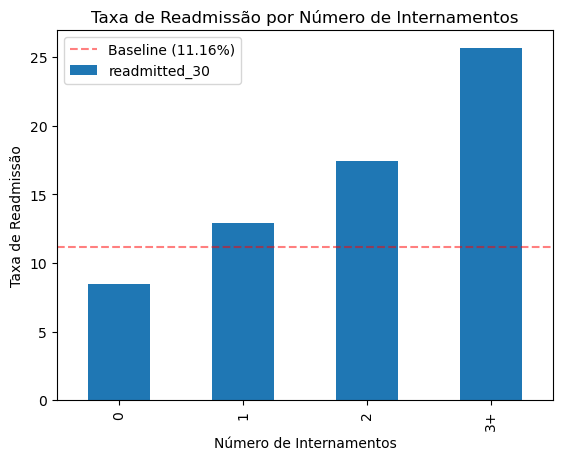

In [184]:
(df.groupby("inpatient_cat")["readmitted_30"].agg("mean")*100).round(2).plot(kind="bar")
plt.title("Taxa de Readmissão por Número de Internamentos")
plt.xlabel("Número de Internamentos")
plt.ylabel("Taxa de Readmissão")
plt.axhline(y=11.16, color='red', linestyle='--', alpha=0.5, label='Baseline (11.16%)')
plt.legend()
plt.show()

In [185]:
(df.groupby("emergency_cat")["readmitted_30"].agg(["mean", "count"]) * [100, 1]).round(2)

,mean,count
emergency_cat,,
0,10.47,90383
1,14.35,7677
2,18.27,2042
3+,24.94,1664


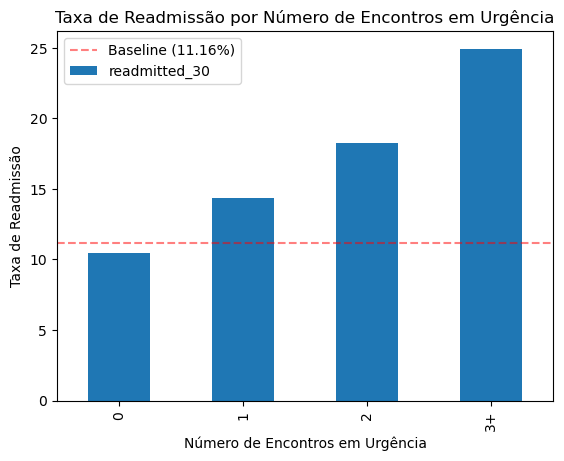

In [186]:
(df.groupby("emergency_cat")["readmitted_30"].agg("mean")*100).round(2).plot(kind="bar")
plt.title("Taxa de Readmissão por Número de Encontros em Urgência")
plt.xlabel("Número de Encontros em Urgência")
plt.ylabel("Taxa de Readmissão")
plt.axhline(y=11.16, color='red', linestyle='--', alpha=0.5, label='Baseline (11.16%)')
plt.legend()
plt.show()

In [187]:
(df.groupby("outpatient_cat")["readmitted_30"].agg(["mean", "count"]) * [100, 1]).round(2)

,mean,count
outpatient_cat,,
0,10.67,85027
1,13.92,8547
2,13.75,3594
3+,12.98,4598


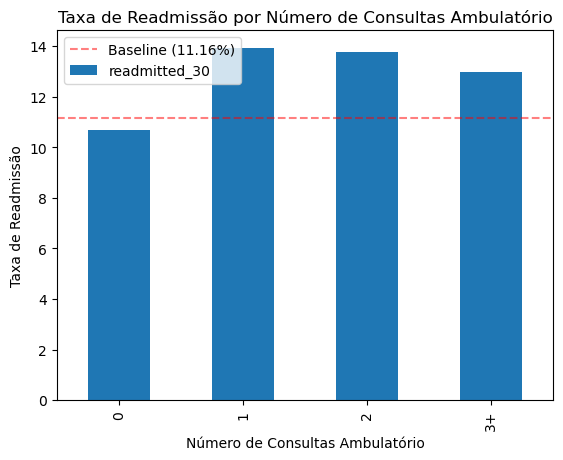

In [188]:
(df.groupby("outpatient_cat")["readmitted_30"].agg("mean")*100).round(2).plot(kind="bar")
plt.title("Taxa de Readmissão por Número de Consultas Ambulatório")
plt.xlabel("Número de Consultas Ambulatório")
plt.ylabel("Taxa de Readmissão")
plt.axhline(y=11.16, color='red', linestyle='--', alpha=0.5, label='Baseline (11.16%)')
plt.legend()
plt.show()

**H5 — Visitas prévias: confirmada com força excecional**

A hipótese confirma-se de forma robusta e produz o sinal mais forte observado em toda a EDA até este ponto. O número de internamentos prévios no ano anterior (`number_inpatient`) discrimina dramaticamente: doentes sem internamentos têm taxa de readmissão de 8.44%, enquanto doentes com 3+ internamentos prévios atingem 25.66% — diferença absoluta de 17.22pp e risco relativo de **3.04×**. Para contexto, `num_medications` (a anterior melhor variável) gerava diferença de 5pp e risco relativo de 1.62×.

A hierarquia clínica antecipada confirma-se integralmente: internamentos prévios (3.04×) > urgências (2.38×) > consultas ambulatórias (1.22×). Esta gradação reflete a especificidade clínica do preditor — quanto mais o preditor é da mesma natureza do desfecho (readmissão = novo internamento), maior a força preditiva. Internamentos prévios são literalmente o mesmo tipo de evento; urgências são porta de entrada para internamento; consultas ambulatórias são de natureza preventiva, qualitativamente diferentes.

A análise de `number_outpatient` revela uma nuance importante: a relação não é monotónica. A taxa sobe de 10.67% (0 consultas) para 13.92% (1 consulta), mas depois estabiliza e ligeiramente desce (12.98% para 3+). Esta forma é compatível com a hipótese clínica de que consultas ambulatórias indexam dois efeitos opostos — gravidade clínica subjacente (eleva risco) e vigilância médica eficaz (atenua risco) — cujo equilíbrio resulta num plateau após o primeiro contacto.

**Implicações para a fase de modelação:** `number_inpatient` antecipa-se como a feature de maior importância preditiva no modelo final. `number_emergency` deverá complementá-la com sinal independente moderado. Para `number_outpatient`, a não-linearidade favorece o uso de gradient boosting sobre regressão logística, ou alternativamente a criação de feature derivada binária (`has_outpatient_visit`) que pode capturar o sinal essencial.

In [189]:
df["A1Cresult"].head()

0    None
1    None
2    None
3    None
4    None
Name: A1Cresult, dtype: object

In [191]:
(df.groupby("A1Cresult")["readmitted_30"].agg(["mean", "count"]) * [100, 1]).round(2)

,mean,count
A1Cresult,,
>7,10.05,3812
>8,9.87,8216
None,11.42,84748
Norm,9.66,4990


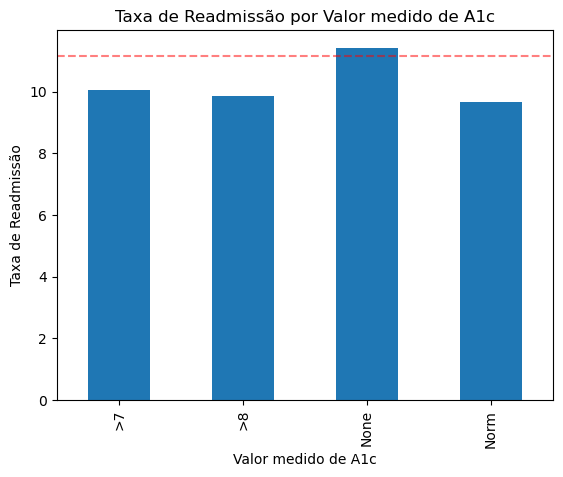

In [194]:
(df.groupby("A1Cresult",observed=True)["readmitted_30"].agg("mean")*100).round(2).plot(kind="bar")
plt.title("Taxa de Readmissão por Valor medido de A1c")
plt.xlabel("Valor medido de A1c")
plt.ylabel("Taxa de Readmissão")
plt.axhline(y=11.16, color='red', linestyle='--', alpha=0.5, label='Baseline (11.16%)')
plt.show()

**H3 — A1c: hipótese desmentida com achado clinicamente interessante**

A análise empírica desmente a hipótese formulada *a priori*. Esperava-se que os doentes com A1c medido (em particular com mau controlo, `>8`) apresentassem taxa de readmissão **superior** aos não medidos, por *confounding by indication* — a decisão de medir refletir gravidade clínica subjacente. Os dados mostram o oposto: a categoria `None` (exame não realizado, n=84.748) tem a **maior** taxa de readmissão (11.42%), acima da baseline geral (11.16%), enquanto as três categorias com A1c medido — `>7` (10.05%), `>8` (9.87%) e `Norm` (9.66%) — apresentam todas taxas **abaixo** da baseline.

Achado adicional, igualmente contra-intuitivo: entre doentes com A1c medido, **a relação dose-resposta esperada não se manifesta**. Pior controlo glicémico (`>8`, A1c acima de 8%) deveria, biologicamente, predizer maior risco de descompensação e readmissão. No entanto, as três categorias medidas situam-se todas próximas dos 10%, com `>8` (9.87%) virtualmente igual a `Norm` (9.66%). A magnitude do controlo glicémico parece, por si só, ter força preditiva fraca para readmissão a 30 dias.

Uma interpretação mecanicista coerente: **medir A1c durante o internamento não é ato passivo — desencadeia intervenção clínica**. Resultado `>8` aciona ajuste terapêutico, reforço educacional ao doente, intensificação de seguimento à alta. Resultado `Norm` alivia preocupação. Em ambos os casos, a medição informa decisão clínica que mitiga risco. Quando A1c **não é medido**, o controlo glicémico permanece desconhecido, o doente sai sem ajuste informado, e o risco basal não é endereçado — explicando a taxa ligeiramente superior na categoria `None`.

*Cuidado epistémico:* a análise demonstra associação, não causalidade. Várias explicações alternativas não podem ser descartadas com a observação disponível. (a) *Selection bias hospitalar*: hospitais com cultura de medir A1c rotineiramente podem partilhar outras boas práticas (protocolos de alta robustos, follow-up estruturado), e o efeito protetor observado pode pertencer ao conjunto, não à medição isolada. (b) *Selection bias do doente*: doentes mais aderentes aceitam melhor exames laboratoriais, mantêm consultas e gerem melhor a doença; os "medidos" podem ser subpopulação com melhor aderência geral. (c) *Reverse causality clínica*: doentes admitidos por crise aguda não-glicémica (ex.: pneumonia, evento cardiovascular) podem ter A1c omitido por foco no problema agudo, e essa gravidade aguda não-diabética explica readmissão.

*Implicações para modelação:* `A1Cresult` permanece informativa pela diferença entre categoria `None` e categorias medidas — esta é a fronteira que carrega sinal preditivo. A granularidade biológica entre `Norm`, `>7` e `>8` parece carregar pouco sinal adicional, sugerindo que uma feature binária derivada (`a1c_measured`) poderia capturar a maior parte da informação preditiva relevante. Será testada como ablação na fase de modelação.

In [196]:
df["payer_code"].value_counts()

payer_code
MC    32439
HM     6274
SP     5007
BC     4655
MD     3532
CP     2533
UN     2448
CM     1937
OG     1033
PO      592
DM      549
CH      146
WC      135
OT       95
MP       79
SI       55
FR        1
Name: count, dtype: int64

In [197]:
df["payer_code"].isna().sum()

40256

In [199]:
def categorize_payer(code):
    if pd.isna(code):
        return "Unknown"
    elif code in ["MC", "MD", "MP", "DM"]:
        return "Public (Medicare/Medicaid)"
    elif code == "SP":
        return "Self-pay"
    else:
        return "Private/Other"

df["payer_group"] = df["payer_code"].apply(categorize_payer)
(df.groupby("payer_group")["readmitted_30"].agg(["mean", "count"]) * [100, 1]).round(2)

,mean,count
payer_group,,
Private/Other,9.65,19904
Public (Medicare/Medicaid),11.75,36599
Self-pay,10.19,5007
Unknown,11.49,40256


In [200]:
df_60_70 = df[df["age"] == "[60-70)"]
(df_60_70.groupby("payer_group")["readmitted_30"].agg(["mean", "count"]) * [100, 1]).round(2)

,mean,count
payer_group,,
Private/Other,10.27,5218
Public (Medicare/Medicaid),11.54,7243
Self-pay,10.71,1130
Unknown,11.35,8892


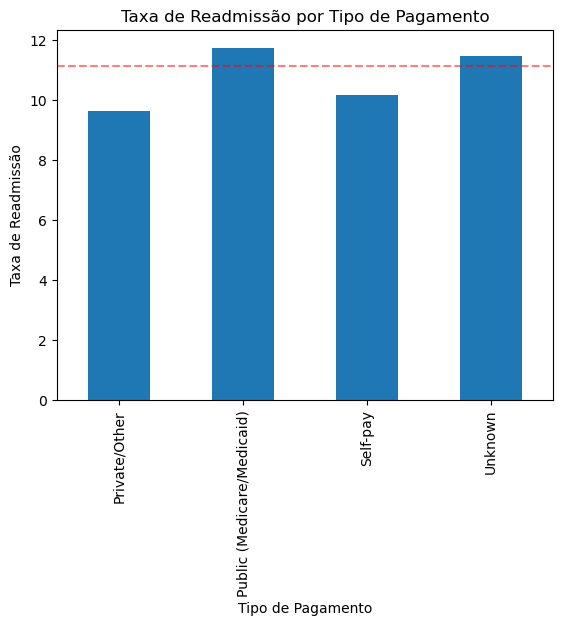

In [201]:
(df.groupby("payer_group",observed=True)["readmitted_30"].agg("mean")*100).round(2).plot(kind="bar")
plt.title("Taxa de Readmissão por Tipo de Pagamento")
plt.xlabel("Tipo de Pagamento")
plt.ylabel("Taxa de Readmissão")
plt.axhline(y=11.16, color='red', linestyle='--', alpha=0.5, label='Baseline (11.16%)')
plt.show()

**H6 — Payer code: confirmada com magnitude moderada e implicações de fairness**

A análise confirma a hipótese: o tipo de pagador associa-se a taxa de readmissão diferenciada. O ranking observado é Public Medicare/Medicaid (11.75%, n=36.599) > Unknown (11.49%, n=40.256) > Self-pay (10.19%, n=5.007) > Private/Other (9.65%, n=19.904). Doentes em seguros públicos apresentam risco aproximadamente 22% superior em termos relativos face a doentes com seguros privados (11.75% vs 9.65%, diferença absoluta de 2.10pp).

A análise estratificada por idade — restringindo a comparação à faixa [60-70), onde Public e Private coexistem em proporções razoáveis — permite decompor o efeito. Na faixa [60-70): Public 11.54%, Private 10.27%, diferença de 1.27pp. Comparando com o dataset completo (diferença de 2.10pp), conclui-se que **aproximadamente 40% do efeito do payer é mediado pela idade** (Medicare está fortemente associada a doentes ≥65), mas **60% persiste como efeito independente** dentro da mesma faixa etária. Esta persistência é evidência de que o `payer_code` capta dimensões para além da idade — provavelmente acesso a cuidados primários, suporte social, literacia em saúde e aderência terapêutica.

A categoria `Unknown` apresenta taxa muito próxima de `Public` (11.49% vs 11.75%), reforçando interpretação consistente com a análise empírica da Secção 4: doentes com `payer_code` não registado tendem a ser servidos por hospitais com administração mais frágil ou populações socioeconomicamente vulneráveis, partilhando perfil de risco com a categoria pública.

**Discussão de algorithmic fairness:** o `payer_code` é uma variável socioeconómica indireta cuja inclusão num modelo preditivo levanta questão ética substantiva. O modelo não aprende causalidade, mas correlação — o seguro em si não causa readmissão; causam-na as condições subjacentes que o seguro indexa (acesso, suporte, aderência). Sem medição direta dessas condições, o modelo usa o seguro como proxy. O risco é o modelo aprender desigualdade estrutural do sistema de saúde, atribuindo scores de risco mais elevados a doentes em Medicare/Medicaid não pelo seu perfil clínico individual, mas pelo perfil socioeconómico médio do grupo. Esta dinâmica está documentada em literatura recente (Obermeyer et al., *Science*, 2019).

**Decisão metodológica para a fase de modelação:** `payer_code` será incluído como feature categórica (4 grupos), mas sujeito a auditoria explícita de *fairness* em pós-processamento. Concretamente, mede-se calibração e métricas de erro (false negative rate, false positive rate) separadamente por grupo de pagador, identificando disparidades sistemáticas. Se forem detetadas, exploram-se técnicas de mitigação — re-weighting, thresholds por grupo, ou ablação completa da feature como sensitivity analysis. A inclusão direta justifica-se pela força preditiva moderada confirmada nesta análise; a auditoria justifica-se pelo risco ético explícito.

## 7. Conclusões da EDA